# Модуль 4: LLM Generation & RAG Evaluation

**Production RAG Pipeline — Финальная часть**

В Модулях 1-3 мы построили retrieval pipeline:
- Модуль 1: Chunking (документ → чанки)
- Модуль 2: Embeddings & Vector Stores (чанки → векторы → поиск)
- Модуль 3: Hybrid Search + Reranking (BM25 + Dense + Cross-Encoder)

Осталось самое важное:
1. **Generation** — подаём найденные чанки в LLM → получаем ответ
2. **Prompt Engineering** — как правильно формировать промпт для RAG
3. **End-to-End Pipeline** — вопрос → retrieval → LLM → ответ
4. **Evaluation (RAGAS-style)** — автоматическая оценка качества RAG

**Используем:** Claude API (Haiku — быстрый и дешёвый для evaluation)

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import anthropic
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    MarkdownHeaderTextSplitter,
)
import chromadb
import re
import time
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Claude API client
client = anthropic.Anthropic()
MODEL = "claude-haiku-4-5-20251001"  # быстрый и дешёвый для учебных целей

# Проверка
resp = client.messages.create(
    model=MODEL, max_tokens=30,
    messages=[{"role": "user", "content": "Ответь одним словом: работает?"}],
)
print(f"Claude API: {resp.content[0].text}")
print(f"Модель: {MODEL}")
print("Все библиотеки загружены")

Claude API: Да.
Модель: claude-haiku-4-5-20251001
Все библиотеки загружены


## Подготовка: Retrieval Pipeline из Модулей 1-3

Переиспользуем два документа и собираем retriever.

In [2]:
LEGAL_DOC_1 = """
# Регламент обработки обращений граждан

## 1. Общие положения

Настоящий регламент устанавливает порядок обработки обращений граждан в электронной форме. Регламент распространяется на все подразделения организации, участвующие в процессе обработки обращений.

Обращение гражданина — это направленное в организацию письменное предложение, заявление или жалоба, а также устное обращение гражданина. Каждое обращение должно быть зарегистрировано в системе в течение одного рабочего дня с момента поступления.

## 2. Классификация обращений

### 2.1 По типу

Обращения классифицируются следующим образом:
- **Предложение** — рекомендация по совершенствованию деятельности организации
- **Заявление** — просьба о содействии в реализации прав и свобод
- **Жалоба** — требование о восстановлении нарушенных прав

### 2.2 По приоритету

Приоритет обращения определяется автоматически на основе следующих критериев:
- **Высокий**: жалобы на нарушение прав, обращения от льготных категорий граждан, повторные обращения
- **Средний**: заявления, требующие межведомственного взаимодействия
- **Низкий**: предложения, информационные запросы

## 3. Процедура обработки

### 3.1 Регистрация

При поступлении обращения оператор выполняет следующие действия:
1. Проверяет полноту заполнения обязательных полей (ФИО, контактные данные, суть обращения)
2. Присваивает регистрационный номер в формате ОГ-ГГГГ-НННННН
3. Определяет тип и приоритет обращения
4. Направляет обращение ответственному исполнителю

### 3.2 Рассмотрение

Ответственный исполнитель обязан:
- Изучить суть обращения в течение 3 рабочих дней
- Запросить дополнительные документы при необходимости
- Подготовить проект ответа
- Согласовать ответ с руководителем подразделения

Срок рассмотрения обращения не должен превышать 30 календарных дней с момента регистрации. В исключительных случаях срок может быть продлён ещё на 30 дней с уведомлением заявителя.

### 3.3 Контроль сроков

Система автоматически отслеживает сроки обработки обращений:
- За 5 дней до истечения срока — уведомление исполнителю
- За 1 день — уведомление исполнителю и руководителю
- При просрочке — эскалация на уровень руководства организации

## 4. Ответственность

За нарушение сроков рассмотрения обращений граждан предусмотрена дисциплинарная ответственность в соответствии с трудовым законодательством Российской Федерации. Повторное нарушение сроков может являться основанием для применения мер дисциплинарного взыскания.
"""

LEGAL_DOC_2 = """
# Положение о персональных данных

## 1. Основные понятия

Персональные данные — любая информация, относящаяся к прямо или косвенно определённому физическому лицу (субъекту персональных данных). К персональным данным относятся: ФИО, дата рождения, адрес, телефон, email, паспортные данные, ИНН, СНИЛС.

Оператор персональных данных — организация, самостоятельно или совместно с другими лицами организующая обработку персональных данных, определяющая цели обработки и состав данных.

## 2. Принципы обработки

### 2.1 Законность и справедливость

Обработка персональных данных осуществляется на законной и справедливой основе. Не допускается обработка данных, несовместимая с целями их сбора. Обработка ограничивается достижением конкретных, заранее определённых и законных целей.

### 2.2 Минимизация данных

Содержание и объём обрабатываемых персональных данных должны соответствовать заявленным целям обработки. Не допускается избыточность данных по отношению к целям их обработки.

## 3. Права субъекта данных

### 3.1 Право на доступ

Субъект персональных данных имеет право получить информацию об обработке его данных, включая:
- Подтверждение факта обработки данных
- Правовые основания и цели обработки
- Способы обработки
- Сроки хранения данных
- Перечень действий с данными

### 3.2 Право на удаление

Субъект данных вправе требовать от оператора уничтожения его персональных данных, если:
- Данные являются незаконно полученными
- Данные не соответствуют заявленным целям обработки
- Истёк срок действия согласия на обработку
- Субъект отзывает согласие на обработку

Оператор обязан уничтожить данные в течение 30 дней с момента получения требования.

## 4. Защита данных

### 4.1 Технические меры

Организация обязана применять следующие технические меры защиты:
- Шифрование данных при передаче (TLS 1.2+) и хранении (AES-256)
- Разграничение доступа на основе ролевой модели (RBAC)
- Журналирование всех операций с персональными данными
- Регулярное резервное копирование
- Проведение аудита безопасности не реже 1 раза в год

### 4.2 Инцидент безопасности

При обнаружении утечки персональных данных оператор обязан:
1. Уведомить Роскомнадзор в течение 24 часов
2. Уведомить субъектов данных в течение 72 часов
3. Провести внутреннее расследование
4. Принять меры по минимизации последствий
5. Задокументировать инцидент и предпринятые меры

## 5. Ответственность

Нарушение законодательства о персональных данных влечёт административную ответственность в виде штрафа: для должностных лиц — до 100 000 рублей, для юридических лиц — до 18 000 000 рублей. За систематические нарушения предусмотрена уголовная ответственность.
"""


# --- Утилиты из предыдущих модулей ---

def chunk_document(doc, chunk_size=400, chunk_overlap=50):
    md_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=[("#", "Документ"), ("##", "Раздел"), ("###", "Подраздел")],
        strip_headers=False,
    )
    header_chunks = md_splitter.split_text(doc)
    recursive_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    chunks = []
    for chunk in header_chunks:
        if len(chunk.page_content) > chunk_size:
            sub = recursive_splitter.create_documents([chunk.page_content], metadatas=[chunk.metadata])
            chunks.extend(sub)
        else:
            chunks.append(chunk)
    return chunks


def tokenize_ru(text):
    stop_words = {
        "и", "в", "на", "с", "по", "не", "для", "от", "из", "к", "о", "а",
        "или", "но", "что", "это", "как", "при", "его", "её", "их", "до",
        "все", "так", "за", "же", "то", "ещё", "уже", "бы", "ли", "ни",
        "об", "во", "со", "без", "под", "над", "между", "через", "после",
        "также", "может", "быть", "должен", "должна", "должно", "являться",
    }
    words = re.findall(r"[а-яёa-z0-9]+", text.lower())
    return [w for w in words if w not in stop_words and len(w) > 1]


# --- Инициализация ---
all_chunks = chunk_document(LEGAL_DOC_1) + chunk_document(LEGAL_DOC_2)
texts = [c.page_content for c in all_chunks]
metadatas = [c.metadata for c in all_chunks]

# BM25
bm25 = BM25Okapi([tokenize_ru(t) for t in texts])

# Dense (E5)
bi_encoder = SentenceTransformer("intfloat/multilingual-e5-base")
embeddings = bi_encoder.encode(
    ["passage: " + t for t in texts], normalize_embeddings=True, show_progress_bar=True,
)

chroma_client = chromadb.Client()
try:
    chroma_client.delete_collection("rag_gen")
except Exception:
    pass
collection = chroma_client.create_collection(name="rag_gen", metadata={"hnsw:space": "cosine"})
collection.add(
    ids=[f"chunk_{i}" for i in range(len(texts))],
    documents=texts,
    embeddings=embeddings.tolist(),
    metadatas=[{"section": m.get("Раздел", ""), "doc": m.get("Документ", "")[:50]} for m in metadatas],
)

print(f"Retriever готов: {len(texts)} чанков, BM25 + Dense (E5)")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


Retriever готов: 18 чанков, BM25 + Dense (E5)


In [3]:
def hybrid_retrieve(query, top_k=3, rrf_k=60):
    """Hybrid retrieval: BM25 + Dense + RRF."""
    # BM25
    bm25_scores = bm25.get_scores(tokenize_ru(query))
    bm25_top = np.argsort(bm25_scores)[::-1][:top_k * 2]
    bm25_results = [(idx, bm25_scores[idx]) for idx in bm25_top if bm25_scores[idx] > 0]

    # Dense
    query_emb = bi_encoder.encode(["query: " + query], normalize_embeddings=True)
    dense_raw = collection.query(query_embeddings=query_emb.tolist(), n_results=min(top_k * 2, len(texts)), include=["distances"])
    dense_results = [(int(d.split("_")[1]), dist) for d, dist in zip(dense_raw["ids"][0], dense_raw["distances"][0])]

    # RRF
    rrf = {}
    for rank, (idx, _) in enumerate(bm25_results):
        rrf[idx] = rrf.get(idx, 0) + 1.0 / (rrf_k + rank + 1)
    for rank, (idx, _) in enumerate(dense_results):
        rrf[idx] = rrf.get(idx, 0) + 1.0 / (rrf_k + rank + 1)

    ranked = sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return [{
        "chunk_idx": idx,
        "text": texts[idx],
        "metadata": metadatas[idx],
        "score": score,
    } for idx, score in ranked]


# Тест
results = hybrid_retrieve("штраф за утечку данных")
print(f"Retrieval test: {len(results)} чанков найдено")
for r in results:
    print(f"  Чанк {r['chunk_idx']}: {r['text'][:80]}...")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Retrieval test: 3 чанков найдено
  Чанк 16: ### 4.2 Инцидент безопасности  
При обнаружении утечки персональных данных опера...
  Чанк 17: ## 5. Ответственность  
Нарушение законодательства о персональных данных влечёт ...
  Чанк 15: ## 4. Защита данных  
### 4.1 Технические меры  
Организация обязана применять с...


---

## Part 1: RAG Generation — базовый вариант

Простейший RAG: берём найденные чанки, вставляем в промпт, получаем ответ.

```
System: Ты юридический ассистент. Отвечай только на основе предоставленного контекста.

User: Контекст:
       [чанк 1]
       [чанк 2]
       [чанк 3]

       Вопрос: ...
```

In [4]:
def rag_generate(query, context_chunks, model=MODEL, temperature=0.0):
    """Генерация ответа на основе найденных чанков."""
    # Формируем контекст
    context_parts = []
    for i, chunk in enumerate(context_chunks, 1):
        source = chunk["metadata"].get("Раздел", chunk["metadata"].get("Подраздел", "Документ"))
        context_parts.append(f"[Источник {i}: {source}]\n{chunk['text']}")
    context = "\n\n".join(context_parts)

    system_prompt = (
        "Ты юридический ассистент. Отвечай строго на основе предоставленного контекста. "
        "Если в контексте нет информации для ответа — скажи об этом прямо. "
        "Не выдумывай и не додумывай. Ссылайся на конкретные источники."
    )

    user_message = f"Контекст:\n{context}\n\nВопрос: {query}"

    response = client.messages.create(
        model=model,
        max_tokens=500,
        temperature=temperature,
        system=system_prompt,
        messages=[{"role": "user", "content": user_message}],
    )

    return {
        "answer": response.content[0].text,
        "usage": {"input": response.usage.input_tokens, "output": response.usage.output_tokens},
        "context": context_chunks,
        "query": query,
    }


# Тест: полный RAG
query = "Какой штраф грозит компании за утечку персональных данных?"
chunks = hybrid_retrieve(query, top_k=3)
result = rag_generate(query, chunks)

print(f"Вопрос: {query}\n")
print(f"Ответ:\n{result['answer']}\n")
print(f"Токены: {result['usage']}")
print(f"Источники: {[c['chunk_idx'] for c in result['context']]}")

Вопрос: Какой штраф грозит компании за утечку персональных данных?

Ответ:
На основе предоставленного контекста я могу дать следующий ответ:

**Штраф за нарушение законодательства о персональных данных для юридических лиц составляет до 18 000 000 рублей** (Источник 1).

Однако важно уточнить: в контексте указан штраф за **нарушение законодательства о персональных данных в целом**, а не конкретно за утечку данных. Контекст не содержит информации о том, предусмотрены ли отдельные размеры штрафов именно за утечку персональных данных или иные специфические нарушения.

Кроме того, контекст указывает, что за **систематические нарушения** предусмотрена **уголовная ответственность** (Источник 1), но конкретные размеры уголовных наказаний в предоставленных материалах не описаны.

Токены: {'input': 493, 'output': 261}
Источники: [np.int64(17), np.int64(16), np.int64(12)]


In [5]:
# Несколько вопросов для демонстрации
test_questions = [
    "Какие виды обращений граждан существуют?",
    "В какой срок нужно уведомить Роскомнадзор при утечке данных?",
    "Как определяется приоритет обращения?",
    "Какие технические меры защиты персональных данных обязательны?",
    "Что происходит при просрочке рассмотрения обращения?",
]

for q in test_questions:
    chunks = hybrid_retrieve(q, top_k=3)
    result = rag_generate(q, chunks)
    print(f"Q: {q}")
    print(f"A: {result['answer'][:200]}{'...' if len(result['answer']) > 200 else ''}")
    print(f"   [{result['usage']['input']}+{result['usage']['output']} tokens]\n")

Q: Какие виды обращений граждан существуют?
A: На основе предоставленного контекста (Источник 3: раздел "2. Классификация обращений"), существуют следующие виды обращений граждан:

1. **Предложение** — рекомендация по совершенствованию деятельност...
   [485+168 tokens]



Q: В какой срок нужно уведомить Роскомнадзор при утечке данных?
A: Согласно [Источнику 1, раздел 4.2 "Инцидент безопасности"], при обнаружении утечки персональных данных оператор обязан **уведомить Роскомнадзор в течение 24 часов**.
   [537+76 tokens]



Q: Как определяется приоритет обращения?
A: Согласно **Источнику 1** (раздел 2.2 "По приоритету"), приоритет обращения определяется **автоматически** на основе следующих критериев:

- **Высокий приоритет**: 
  - жалобы на нарушение прав
  - обр...
   [521+231 tokens]



Q: Какие технические меры защиты персональных данных обязательны?
A: На основе предоставленного контекста (Источник 1, раздел 4.1), организация обязана применять следующие технические меры защиты персональных данных:

1. **Шифрование данных**:
   - При передаче: TLS 1....
   [556+212 tokens]



Q: Что происходит при просрочке рассмотрения обращения?
A: На основе предоставленного контекста при просрочке рассмотрения обращения происходит следующее:

**Автоматическая эскалация:**
Согласно Источнику 2 (раздел 3.3 "Контроль сроков"), при просрочке срока ...
   [457+255 tokens]



---

## Part 2: Prompt Engineering для RAG

Промпт — самая важная часть RAG после retrieval. Сравним несколько стратегий:

| Стратегия | Описание | Когда использовать |
|-----------|----------|-------------------|
| **Базовый** | "Ответь на вопрос по контексту" | Прототип |
| **С цитатами** | Требуем цитировать источник | Юридические/медицинские системы |
| **Chain-of-Thought** | Сначала рассуждение, потом ответ | Сложные вопросы |
| **Structured Output** | JSON с ответом + confidence + sources | API-интеграции |

In [6]:
PROMPT_STRATEGIES = {
    "basic": {
        "system": (
            "Ты юридический ассистент. Отвечай на основе предоставленного контекста. "
            "Если информации нет — скажи об этом."
        ),
        "template": "Контекст:\n{context}\n\nВопрос: {query}",
    },
    "citations": {
        "system": (
            "Ты юридический ассистент. Правила:\n"
            "1. Отвечай ТОЛЬКО на основе предоставленного контекста\n"
            "2. Каждое утверждение подкрепляй ссылкой на источник в формате [Источник N]\n"
            "3. Если в контексте нет ответа — скажи: 'Информация не найдена в предоставленных документах'\n"
            "4. Не добавляй информацию из своих знаний"
        ),
        "template": "Контекст:\n{context}\n\nВопрос: {query}\n\nОтветь со ссылками на источники.",
    },
    "cot": {
        "system": (
            "Ты юридический ассистент. Отвечай по шагам:\n"
            "1. <reasoning>Какие фрагменты контекста релевантны вопросу?</reasoning>\n"
            "2. <answer>Итоговый ответ на вопрос</answer>\n"
            "Используй только информацию из контекста."
        ),
        "template": "Контекст:\n{context}\n\nВопрос: {query}",
    },
    "structured": {
        "system": (
            "Ты юридический ассистент. Отвечай строго в JSON формате:\n"
            '{"answer": "текст ответа", "confidence": "high/medium/low", '
            '"sources": [номера использованных источников], '
            '"has_answer": true/false}\n'
            "Если в контексте нет ответа: has_answer=false, confidence=low."
        ),
        "template": "Контекст:\n{context}\n\nВопрос: {query}\n\nОтветь в JSON.",
    },
}


def rag_with_strategy(query, context_chunks, strategy="basic", model=MODEL):
    """RAG с разными prompt-стратегиями."""
    config = PROMPT_STRATEGIES[strategy]

    context_parts = []
    for i, chunk in enumerate(context_chunks, 1):
        source = chunk["metadata"].get("Раздел", chunk["metadata"].get("Подраздел", ""))
        context_parts.append(f"[Источник {i}: {source}]\n{chunk['text']}")
    context = "\n\n".join(context_parts)

    user_message = config["template"].format(context=context, query=query)

    response = client.messages.create(
        model=model, max_tokens=600, temperature=0.0,
        system=config["system"],
        messages=[{"role": "user", "content": user_message}],
    )
    return response.content[0].text


# Сравнение стратегий на одном вопросе
query = "Что делать при обнаружении утечки персональных данных?"
chunks = hybrid_retrieve(query, top_k=3)

for name in PROMPT_STRATEGIES:
    answer = rag_with_strategy(query, chunks, strategy=name)
    print(f"\n{'='*60}")
    print(f"Стратегия: {name.upper()}")
    print(f"{'='*60}")
    print(answer[:400])
    if len(answer) > 400:
        print("...")


Стратегия: BASIC
# Действия при обнаружении утечки персональных данных

При обнаружении утечки персональных данных оператор обязан выполнить следующие действия:

1. **Уведомить Роскомнадзор** — в течение **24 часов**

2. **Уведомить субъектов данных** — в течение **72 часов**

3. **Провести внутреннее расследование** — установить причины и масштабы инцидента

4. **Принять меры по минимизации последствий** — ограни
...



Стратегия: CITATIONS
При обнаружении утечки персональных данных оператор обязан выполнить следующие действия [Источник 1]:

1. **Уведомить Роскомнадзор в течение 24 часов** [Источник 1]
2. **Уведомить субъектов данных в течение 72 часов** [Источник 1]
3. **Провести внутреннее расследование** [Источник 1]
4. **Принять меры по минимизации последствий** [Источник 1]
5. **Задокументировать инцидент и предпринятые меры** [
...



Стратегия: COT
<reasoning>
Вопрос касается действий при обнаружении утечки персональных данных. Релевантная информация находится в Источнике 1, раздел 4.2 "Инцидент безопасности", который содержит пошаговый список обязательных действий оператора.
</reasoning>

<answer>
При обнаружении утечки персональных данных оператор обязан выполнить следующие действия:

1. **Уведомить Роскомнадзор** в течение 24 часов
2. **У
...



Стратегия: STRUCTURED
```json
{
  "answer": "При обнаружении утечки персональных данных оператор обязан: 1) Уведомить Роскомнадзор в течение 24 часов; 2) Уведомить субъектов данных в течение 72 часов; 3) Провести внутреннее расследование; 4) Принять меры по минимизации последствий; 5) Задокументировать инцидент и предпринятые меры.",
  "confidence": "high",
  "sources": [1],
  "has_answer": true
}
```


### Антигаллюцинация: тест на вопрос без ответа

Критически важно: RAG должен **отказываться отвечать**, если в контексте нет информации.
Иначе LLM нагаллюцинирует ответ из своих знаний — и пользователь получит выдумку, оформленную как факт.

In [7]:
# Вопрос, на который в наших документах НЕТ ответа
unanswerable = "Какие штрафы за нарушение GDPR в Евросоюзе?"
chunks = hybrid_retrieve(unanswerable, top_k=3)

print(f"Вопрос: {unanswerable}")
print(f"(В наших документах — только РФ законодательство, не GDPR)\n")

for name in ["basic", "citations", "structured"]:
    answer = rag_with_strategy(unanswerable, chunks, strategy=name)
    print(f"{name.upper()}:")
    print(f"  {answer[:250]}")
    print()

Вопрос: Какие штрафы за нарушение GDPR в Евросоюзе?
(В наших документах — только РФ законодательство, не GDPR)



BASIC:
  На основе предоставленного контекста я не могу ответить на ваш вопрос о штрафах за нарушение GDPR в Евросоюзе.

Контекст содержит информацию только о штрафах за нарушение **российского законодательства о персональных данных**:
- Для должностных лиц —



CITATIONS:
  Информация не найдена в предоставленных документах.

Предоставленные источники содержат информацию о штрафах за нарушение законодательства о персональных данных в Российской Федерации [Источник 1], но не содержат сведений о штрафах за нарушение GDPR 



STRUCTURED:
  ```json
{
  "answer": "В предоставленном контексте отсутствует информация о штрафах за нарушение GDPR в Евросоюзе. Контекст содержит информацию о штрафах за нарушение законодательства о персональных данных в Российской Федерации (административные штр



---

## Part 3: End-to-End RAG Pipeline

Полный pipeline в одном классе.

In [8]:
class RAGPipeline:
    """End-to-End RAG: Hybrid Retrieval → LLM Generation."""

    def __init__(self, model=MODEL, prompt_strategy="citations"):
        self.model = model
        self.strategy = prompt_strategy
        self.client = anthropic.Anthropic()
        self.bi_encoder = SentenceTransformer("intfloat/multilingual-e5-base")
        self.bm25 = None
        self.collection = None
        self.chroma_client = chromadb.Client()
        self.texts = []
        self.metadatas = []

    def ingest(self, documents):
        """Загрузить документы."""
        chunks = []
        for doc in documents:
            chunks.extend(chunk_document(doc))

        self.texts = [c.page_content for c in chunks]
        self.metadatas = [c.metadata for c in chunks]

        # BM25
        self.bm25 = BM25Okapi([tokenize_ru(t) for t in self.texts])

        # Dense
        embs = self.bi_encoder.encode(
            ["passage: " + t for t in self.texts],
            normalize_embeddings=True, show_progress_bar=True,
        )
        try:
            self.chroma_client.delete_collection("e2e_rag")
        except Exception:
            pass
        self.collection = self.chroma_client.create_collection(name="e2e_rag", metadata={"hnsw:space": "cosine"})
        self.collection.add(
            ids=[f"c_{i}" for i in range(len(self.texts))],
            documents=self.texts,
            embeddings=embs.tolist(),
            metadatas=[{"section": m.get("Раздел", ""), "doc": m.get("Документ", "")[:50]} for m in self.metadatas],
        )
        print(f"Загружено {len(self.texts)} чанков")
        return self

    def retrieve(self, query, top_k=3, rrf_k=60):
        """Hybrid retrieval."""
        bm25_scores = self.bm25.get_scores(tokenize_ru(query))
        bm25_top = np.argsort(bm25_scores)[::-1][:top_k * 2]
        bm25_results = [(idx, bm25_scores[idx]) for idx in bm25_top if bm25_scores[idx] > 0]

        query_emb = self.bi_encoder.encode(["query: " + query], normalize_embeddings=True)
        dense_raw = self.collection.query(
            query_embeddings=query_emb.tolist(),
            n_results=min(top_k * 2, len(self.texts)),
            include=["distances"],
        )
        dense_results = [(int(d.split("_")[1]), dist) for d, dist in zip(dense_raw["ids"][0], dense_raw["distances"][0])]

        rrf = {}
        for rank, (idx, _) in enumerate(bm25_results):
            rrf[idx] = rrf.get(idx, 0) + 1.0 / (rrf_k + rank + 1)
        for rank, (idx, _) in enumerate(dense_results):
            rrf[idx] = rrf.get(idx, 0) + 1.0 / (rrf_k + rank + 1)

        ranked = sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:top_k]
        return [{"chunk_idx": idx, "text": self.texts[idx], "metadata": self.metadatas[idx], "score": score} for idx, score in ranked]

    def generate(self, query, context_chunks, temperature=0.0):
        """LLM generation с выбранной стратегией."""
        config = PROMPT_STRATEGIES[self.strategy]
        context_parts = []
        for i, chunk in enumerate(context_chunks, 1):
            source = chunk["metadata"].get("Раздел", chunk["metadata"].get("Подраздел", ""))
            context_parts.append(f"[Источник {i}: {source}]\n{chunk['text']}")
        context = "\n\n".join(context_parts)

        response = self.client.messages.create(
            model=self.model, max_tokens=500, temperature=temperature,
            system=config["system"],
            messages=[{"role": "user", "content": config["template"].format(context=context, query=query)}],
        )
        return response.content[0].text, response.usage

    def ask(self, query, top_k=3):
        """Полный RAG: retrieve → generate."""
        start = time.time()
        chunks = self.retrieve(query, top_k=top_k)
        retrieve_time = time.time() - start

        start = time.time()
        answer, usage = self.generate(query, chunks)
        generate_time = time.time() - start

        return {
            "query": query,
            "answer": answer,
            "chunks": chunks,
            "usage": {"input": usage.input_tokens, "output": usage.output_tokens},
            "timing": {"retrieve_ms": int(retrieve_time * 1000), "generate_ms": int(generate_time * 1000)},
        }


# Создаём и тестируем
rag = RAGPipeline(prompt_strategy="citations")
rag.ingest([LEGAL_DOC_1, LEGAL_DOC_2])

print("\n" + "=" * 60)
result = rag.ask("Какие права есть у человека в отношении его персональных данных?")
print(f"Q: {result['query']}")
print(f"\nA: {result['answer']}")
print(f"\nRetrieval: {result['timing']['retrieve_ms']}ms | Generation: {result['timing']['generate_ms']}ms")
print(f"Токены: input={result['usage']['input']}, output={result['usage']['output']}")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


Загружено 18 чанков



Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Q: Какие права есть у человека в отношении его персональных данных?

A: На основе предоставленных документов, у человека (субъекта персональных данных) есть следующие права:

## Право на доступ [Источник 1]

Субъект персональных данных имеет право получить информацию об обработке его данных, включая [Источник 1]:

- Подтверждение факта обработки данных
- Правовые основания и цели обработки
- Способы обработки
- Сроки хранения данных
- Перечень действий с данными

---

**Примечание:** В предоставленных документах описано только право на доступ. Информация о других правах субъектов персональных данных (например, право на исправление, удаление, возражение и т.д.) не найдена в предоставленных источниках.

Retrieval: 232ms | Generation: 9250ms
Токены: input=527, output=222


---

## Part 4: RAG Evaluation (RAGAS-style)

**RAGAS** (Retrieval-Augmented Generation Assessment) — фреймворк для автоматической оценки RAG.

Ключевые метрики:

| Метрика | Что оценивает | Как работает |
|---------|--------------|-------------|
| **Faithfulness** | Ответ основан на контексте? | LLM проверяет каждое утверждение |
| **Answer Relevancy** | Ответ отвечает на вопрос? | LLM оценивает соответствие |
| **Context Relevancy** | Найденные чанки релевантны? | LLM проверяет каждый чанк |
| **Answer Correctness** | Ответ фактически верен? | Сравнение с ground truth |

Мы реализуем эти метрики с помощью Claude (LLM-as-judge).

**Java-аналогия:** integration tests для RAG — проверяем не отдельные компоненты, а весь pipeline.

In [9]:
def llm_judge(prompt, model=MODEL):
    """Вызов LLM-as-judge для evaluation."""
    response = client.messages.create(
        model=model, max_tokens=300, temperature=0.0,
        messages=[{"role": "user", "content": prompt}],
    )
    return response.content[0].text


def eval_faithfulness(answer, context):
    """Faithfulness: ответ основан на контексте? Score 0-1."""
    prompt = f"""Оцени, насколько ответ основан на предоставленном контексте.

Контекст:
{context}

Ответ:
{answer}

Инструкция:
1. Выдели каждое фактическое утверждение в ответе
2. Проверь, есть ли для него подтверждение в контексте
3. Верни JSON: {{"score": 0.0-1.0, "explanation": "краткое пояснение"}}
   score = (кол-во подтверждённых утверждений) / (общее кол-во утверждений)

Только JSON, без дополнительного текста."""
    return llm_judge(prompt)


def eval_answer_relevancy(query, answer):
    """Answer Relevancy: ответ отвечает на вопрос? Score 0-1."""
    prompt = f"""Оцени, насколько ответ релевантен вопросу.

Вопрос: {query}

Ответ: {answer}

Критерии:
- 1.0: полностью отвечает на вопрос
- 0.7-0.9: отвечает, но не полностью или с лишней информацией
- 0.4-0.6: частично отвечает
- 0.1-0.3: почти не отвечает
- 0.0: совершенно не по теме

Верни JSON: {{"score": 0.0-1.0, "explanation": "краткое пояснение"}}
Только JSON."""
    return llm_judge(prompt)


def eval_context_relevancy(query, context_chunks):
    """Context Relevancy: найденные чанки релевантны вопросу? Score 0-1."""
    chunks_text = "\n---\n".join([f"Чанк {i+1}: {c['text'][:200]}" for i, c in enumerate(context_chunks)])
    prompt = f"""Оцени релевантность найденных чанков вопросу.

Вопрос: {query}

Найденные чанки:
{chunks_text}

Для каждого чанка определи: релевантен ли он вопросу?
Верни JSON: {{"score": 0.0-1.0, "relevant_chunks": [номера], "explanation": "пояснение"}}
   score = (релевантные чанки) / (всего чанков)
Только JSON."""
    return llm_judge(prompt)


def parse_score(judge_response):
    """Извлечь score из JSON-ответа LLM."""
    try:
        # Ищем JSON в ответе
        match = re.search(r'\{[^}]+\}', judge_response)
        if match:
            data = json.loads(match.group())
            return float(data.get("score", 0))
    except (json.JSONDecodeError, ValueError):
        pass
    return 0.0


# Тест evaluation на одном вопросе
query = "В какой срок нужно уведомить Роскомнадзор при утечке данных?"
result = rag.ask(query)

print(f"Q: {query}")
print(f"A: {result['answer']}\n")

context_text = "\n".join([c["text"] for c in result["chunks"]])

faith = eval_faithfulness(result["answer"], context_text)
relev = eval_answer_relevancy(query, result["answer"])
ctx = eval_context_relevancy(query, result["chunks"])

print(f"Faithfulness:       {parse_score(faith):.2f}  {faith}")
print(f"Answer Relevancy:   {parse_score(relev):.2f}  {relev}")
print(f"Context Relevancy:  {parse_score(ctx):.2f}  {ctx}")

Q: В какой срок нужно уведомить Роскомнадзор при утечке данных?
A: При обнаружении утечки персональных данных оператор обязан уведомить Роскомнадзор в течение **24 часов** [Источник 1].



Faithfulness:       1.00  ```json
{
  "score": 1.0,
  "explanation": "Ответ содержит одно фактическое утверждение: 'оператор обязан уведомить Роскомнадзор в течение 24 часов при обнаружении утечки персональных данных'. Это утверждение полностью подтверждается контекстом (раздел 4.2, пункт 1). Источник корректно указан."
}
```
Answer Relevancy:   0.85  ```json
{
  "score": 0.85,
  "explanation": "Ответ прямо и точно указывает требуемый срок (24 часа), что полностью соответствует вопросу. Минус в оценке за отсутствие уточнений о том, что это касается уведомления Роскомнадзора именно об утечках, повлекших нарушение безопасности данных, и отсутствие информации об уведомлении самих субъектов данных (которое требуется в течение 30 дней). Однако основной вопрос раскрыт полностью."
}
```
Context Relevancy:  0.33  ```json
{
  "score": 0.33,
  "relevant_chunks": [1],
  "explanation": "Чанк 1 напрямую отвечает на вопрос, указывая срок уведомления Роскомнадзора при утечке данных (24 часа). Чанк 2 

In [10]:
# Полный evaluation на тестовом наборе

eval_set = [
    {
        "query": "Какие виды обращений граждан существуют?",
        "expected_keywords": ["предложение", "заявление", "жалоба"],
    },
    {
        "query": "Какой срок рассмотрения обращения гражданина?",
        "expected_keywords": ["30", "календарных", "дней"],
    },
    {
        "query": "Что делать при утечке персональных данных?",
        "expected_keywords": ["роскомнадзор", "24", "72", "расследование"],
    },
    {
        "query": "Какой штраф за нарушение закона о персональных данных?",
        "expected_keywords": ["18", "000", "000", "штраф"],
    },
    {
        "query": "Как субъект может удалить свои персональные данные?",
        "expected_keywords": ["требовать", "уничтож", "30", "дней"],
    },
    {
        "query": "Какие правила шифрования данных?",  # есть в контексте
        "expected_keywords": ["aes", "tls", "шифрован"],
    },
    {
        "query": "Какие штрафы по GDPR в Евросоюзе?",  # НЕТ в контексте
        "expected_keywords": [],  # должен отказаться отвечать
    },
]

print(f"Evaluation: {len(eval_set)} вопросов\n")

all_scores = {"faithfulness": [], "answer_relevancy": [], "context_relevancy": [], "keyword_hit": []}

for item in eval_set:
    q = item["query"]
    result = rag.ask(q)
    answer = result["answer"]
    context_text = "\n".join([c["text"] for c in result["chunks"]])

    # LLM-as-judge metrics
    faith_score = parse_score(eval_faithfulness(answer, context_text))
    relev_score = parse_score(eval_answer_relevancy(q, answer))
    ctx_score = parse_score(eval_context_relevancy(q, result["chunks"]))

    # Keyword hit rate (простая автометрика без LLM)
    answer_lower = answer.lower()
    if item["expected_keywords"]:
        hits = sum(1 for kw in item["expected_keywords"] if kw.lower() in answer_lower)
        kw_score = hits / len(item["expected_keywords"])
    else:
        # Для вопроса без ответа: проверяем, что модель отказалась
        refusal_markers = ["не найден", "нет информации", "не содержи", "отсутствует", "не упоминает"]
        kw_score = 1.0 if any(m in answer_lower for m in refusal_markers) else 0.0

    all_scores["faithfulness"].append(faith_score)
    all_scores["answer_relevancy"].append(relev_score)
    all_scores["context_relevancy"].append(ctx_score)
    all_scores["keyword_hit"].append(kw_score)

    status = "✓" if kw_score > 0.5 else "✗"
    print(f"{status} \"{q}\"")
    print(f"  Faith={faith_score:.2f} | Relev={relev_score:.2f} | Ctx={ctx_score:.2f} | KW={kw_score:.2f}")
    print(f"  A: {answer[:120]}...\n")

# Итоги
print("=" * 70)
print("ИТОГО:")
for metric, scores in all_scores.items():
    print(f"  {metric:<20}: {np.mean(scores):.3f} (min={min(scores):.2f}, max={max(scores):.2f})")

Evaluation: 7 вопросов



✓ "Какие виды обращений граждан существуют?"
  Faith=1.00 | Relev=0.90 | Ctx=0.67 | KW=1.00
  A: На основе предоставленного контекста существуют следующие виды обращений граждан [Источник 3]:

1. **Предложение** — рек...



✓ "Какой срок рассмотрения обращения гражданина?"
  Faith=1.00 | Relev=0.90 | Ctx=0.67 | KW=1.00
  A: Согласно предоставленным документам, срок рассмотрения обращения гражданина составляет **30 календарных дней** с момента...



✓ "Что делать при утечке персональных данных?"
  Faith=1.00 | Relev=0.85 | Ctx=0.33 | KW=1.00
  A: При утечке персональных данных оператор обязан выполнить следующие действия [Источник 1]:

1. **Уведомить Роскомнадзор в...



✓ "Какой штраф за нарушение закона о персональных данных?"
  Faith=1.00 | Relev=0.85 | Ctx=0.33 | KW=1.00
  A: На основе предоставленного контекста:

Штраф за нарушение законодательства о персональных данных зависит от статуса нару...



✓ "Как субъект может удалить свои персональные данные?"
  Faith=1.00 | Relev=0.85 | Ctx=0.67 | KW=0.75
  A: # Процедура удаления персональных данных

Субъект данных может удалить свои персональные данные, подав требование операт...



✓ "Какие правила шифрования данных?"
  Faith=1.00 | Relev=0.80 | Ctx=0.33 | KW=1.00
  A: # Правила шифрования данных

Согласно предоставленным документам, организация обязана применять следующие правила шифров...



✓ "Какие штрафы по GDPR в Евросоюзе?"
  Faith=0.50 | Relev=0.80 | Ctx=0.33 | KW=1.00
  A: Информация не найдена в предоставленных документах.

Предоставленный контекст содержит информацию о штрафах по российско...

ИТОГО:
  faithfulness        : 0.929 (min=0.50, max=1.00)
  answer_relevancy    : 0.850 (min=0.80, max=0.90)
  context_relevancy   : 0.476 (min=0.33, max=0.67)
  keyword_hit         : 0.964 (min=0.75, max=1.00)


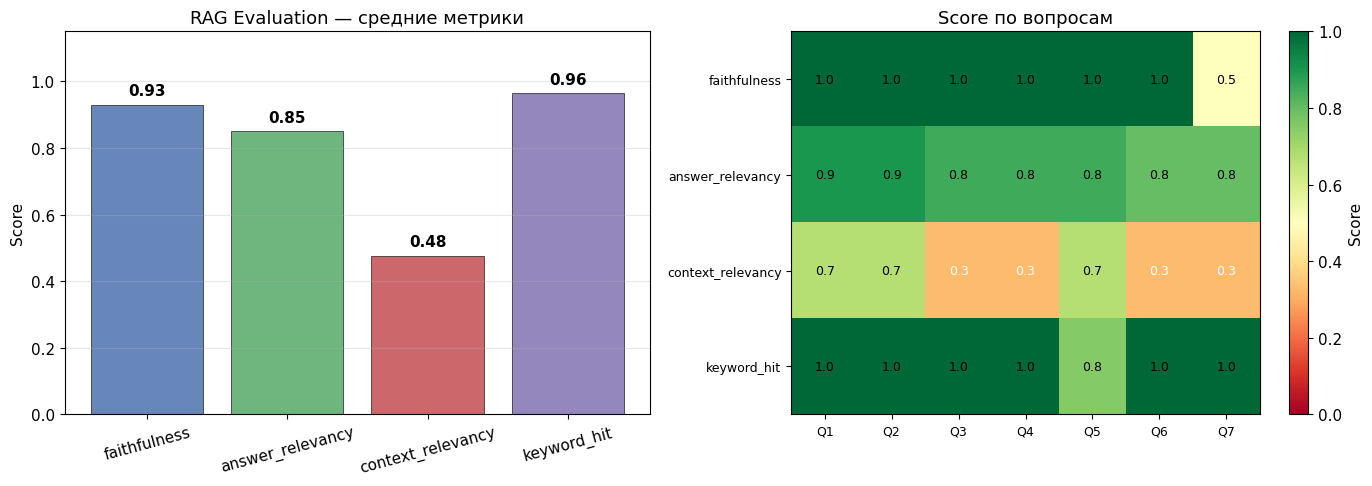

Q1-Q6: вопросы с ответом | Q7: вопрос без ответа (тест антигаллюцинации)


In [11]:
# Визуализация результатов evaluation

metrics = list(all_scores.keys())
means = [np.mean(v) for v in all_scores.values()]
mins = [min(v) for v in all_scores.values()]
maxs = [max(v) for v in all_scores.values()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — средние значения
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
bars = ax1.bar(metrics, means, color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.set_ylim(0, 1.15)
ax1.set_ylabel("Score")
ax1.set_title("RAG Evaluation — средние метрики", fontsize=13)
ax1.tick_params(axis="x", rotation=15)
ax1.grid(axis="y", alpha=0.3)

# Radar / per-question heatmap
questions_short = [q["query"][:35] + "..." for q in eval_set]
data = np.array([all_scores[m] for m in metrics])

im = ax2.imshow(data, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax2.set_yticks(range(len(metrics)))
ax2.set_yticklabels(metrics, fontsize=9)
ax2.set_xticks(range(len(questions_short)))
ax2.set_xticklabels([f"Q{i+1}" for i in range(len(questions_short))], fontsize=9)

for i in range(len(metrics)):
    for j in range(len(eval_set)):
        color = "white" if data[i, j] < 0.5 else "black"
        ax2.text(j, i, f"{data[i, j]:.1f}", ha="center", va="center", fontsize=9, color=color)

plt.colorbar(im, ax=ax2, label="Score")
ax2.set_title("Score по вопросам", fontsize=13)

plt.tight_layout()
plt.show()

print("Q1-Q6: вопросы с ответом | Q7: вопрос без ответа (тест антигаллюцинации)")

---

## Итоговые выводы

### Production RAG Pipeline — полный стек

| Модуль | Компонент | Технология |
|--------|-----------|------------|
| **1. Chunking** | Документ → чанки | Markdown Headers + Recursive |
| **2. Embeddings** | Чанки → векторы | multilingual-e5-base (768-dim) |
| **2. Vector Store** | Хранение + поиск | ChromaDB (прототип) / FAISS (production) |
| **3. Sparse Retrieval** | Точные термины | BM25 (rank_bm25) |
| **3. Hybrid Search** | Dense + Sparse | Reciprocal Rank Fusion (RRF) |
| **3. Reranking** | Переранжирование | Cross-Encoder (sentence-transformers) |
| **4. Generation** | Контекст → ответ | Claude API (Haiku) |
| **4. Prompt Strategy** | Промпт-инженеринг | Citations / CoT / Structured |
| **4. Evaluation** | Качество RAG | LLM-as-Judge (RAGAS-style) |

### Ключевые уроки

1. **Retrieval > Generation.** Если чанк не найден — даже GPT-4 не поможет. 80% качества RAG — в retrieval.
2. **Hybrid Search — must-have.** BM25 ловит точные термины, embeddings — смысл. Вместе лучше.
3. **Prompt strategy matters.** Citations-промпт снижает галлюцинации. Structured — для API.
4. **Evaluation — не опционально.** Без метрик невозможно сравнить конфигурации. LLM-as-Judge — рабочий подход.
5. **Антигаллюцинация.** RAG должен уметь отказываться отвечать — это не баг, а фича.

### Что дальше

- **Применение к LegalBPM KB:** загрузить реальные 366 документов
- **Streaming:** потоковая генерация ответов
- **Caching:** кэширование embeddings для ускорения
- **Multi-turn:** диалоговый RAG с историей
- **Fine-tuning retriever:** дообучение E5 на юридических данных